In [1]:
# # Sweep Results Visualization 
#
# This notebook loads sweep_results.csv and produces:
# 1) Metric heatmaps per controller with shared color scale
# 2) Heatmaps for t_settle_after and ITAE (shared color scales, brighter = better)


# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import matplotlib.lines as mlines



In [2]:
# %%
# Path to the sweep results CSV (edit if needed)
CSV_PATH = "sweep_results/sweep_results_7_by_7.csv"

df = pd.read_csv(CSV_PATH)

required_cols = {"perturb_percent", "perturb_time", "controller", "metric_M", "t_settle_after", "ITAE"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

df.head()

,perturb_percent,perturb_time,controller,t_settle_after,ITAE,metric_M,rise_time,overshoot,settling_time_abs,rank_M,is_best
0,20,360,aPID,199.222222,3791.806527,0.600764,-40.565657,5.398456,559.222222,1.0,True
1,20,360,FF,600.000000,9440.152211,1.598028,-40.565657,1.545814,960.000000,5.0,False
2,20,360,PID-FF,384.636364,6259.331703,1.045957,-40.565657,8.929543,744.636364,4.0,False
3,20,360,aPID-FF,295.929293,4405.013261,0.762602,-40.565657,6.967935,655.929293,2.0,False
4,20,360,PID,330.575758,4938.354511,0.853660,-40.565657,7.687703,690.575758,3.0,False


In [3]:
# %%
# Ensure consistent ordering on axes
percents = np.sort(df["perturb_percent"].unique())
times = np.sort(df["perturb_time"].unique())

# controllers_sorted = sorted(df["controller"].unique())
controllers_sorted = ['PID', 'aPID', 'aPID-FF']

# Color dictionary
color_dict = {
    'set_point_1': '#6759d4',
    'set_point_2': '#ebab4b',
    'green': 'green',
    'red': 'red',
    'PID': 'black',
    'aPID': '#1f78b4', 
    'FF': '#dd3497',
    'PID-FF': '#fc8d62',
    'aPID-FF': '#03cea4'
}

print("percents:", percents)
print("times:", times)
print("controllers:", controllers_sorted)

percents: [20 30 40 50 60 70 80]
times: [360 390 420 450 480 510 540]
controllers: ['PID', 'aPID', 'aPID-FF']


In [ ]:
# Helper functions
def pivot_metric(df_in: pd.DataFrame, controller: str, value_col: str) -> pd.DataFrame:
    sub = df_in[df_in["controller"] == controller].copy()
    mat = sub.pivot(index="perturb_percent", columns="perturb_time", values=value_col)
    mat = mat.reindex(index=percents, columns=times)
    return mat

Global t_settle_after limits: 0.0 600.0
Global ITAE limits: 354.31662838130563 13670.703957043608


Global 1/ITAE limits: 0.0002 0.001


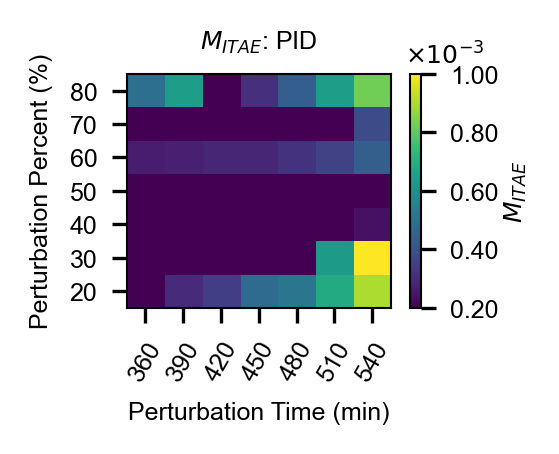

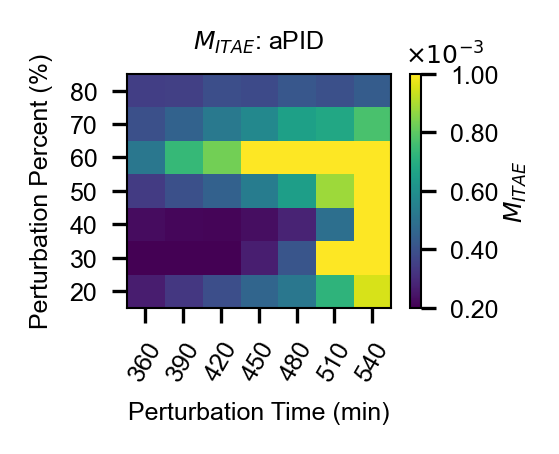

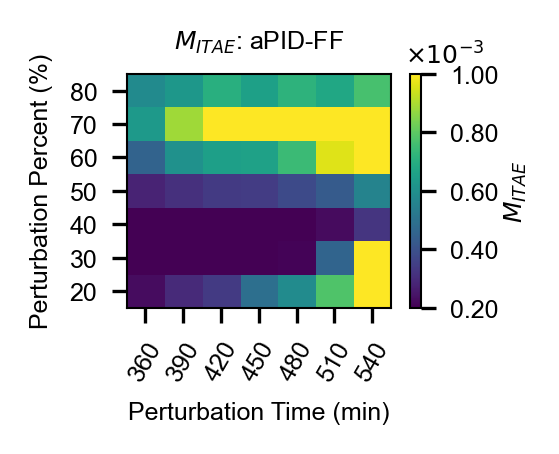

In [5]:
# %%
# Publication Quality Figures:
# Heatmaps of 1/ITAE for each controller
# One config dict used for all individual heatmap figures

heatmap_cfg = {
    'figsize': (1.75, 1.4),
    'dpi': 300,
    'font_family': 'Arial',
    'base_fontsize': 6,
    'title_fontsize': 6,
    'label_fontsize': 6,
    'tick_fontsize': 6,
    'cbar_label_fontsize': 6,
    'spine_linewidth': 0.5,
    'xtick_rotation': 60,
    'cmap': 'viridis',
    'interpolation': 'nearest',
    'aspect': 'auto',
    'origin': 'lower',
    'cbar_orientation': 'vertical',
    'cbar_shrink': 1,
    'cbar_pad': 0.05,
    'cbar_labelpad': 1
}

plt.rcParams.update({
    'font.family': heatmap_cfg['font_family'],
    'font.size': heatmap_cfg['base_fontsize'],
    'axes.labelsize': heatmap_cfg['label_fontsize'],
    'axes.titlesize': heatmap_cfg['title_fontsize'],
    'xtick.labelsize': heatmap_cfg['tick_fontsize'],
    'ytick.labelsize': heatmap_cfg['tick_fontsize']
})

controller_labels = {
    'PID': 'PID',
    'aPID': 'aPID',
    'aPID-FF': 'aPID-FF'
}

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import FuncFormatter

# Calculate global shared limits for 1/ITAE across all controllers
itae_values = df["ITAE"].to_numpy(dtype=float)

valid_itae = itae_values[np.isfinite(itae_values) & (itae_values > 0)]
inv_itae_values = 1.0 / valid_itae

inv_itae_vmin = 0.0002
inv_itae_vmax = 0.001

print("Global 1/ITAE limits:", inv_itae_vmin, inv_itae_vmax)

# Determine common scientific-notation exponent
max_abs = max(abs(inv_itae_vmin), abs(inv_itae_vmax))
sci_exp = int(np.floor(np.log10(max_abs)))

for ctrl in controllers_sorted:

    fig, ax = plt.subplots(
        figsize=heatmap_cfg['figsize'],
        dpi=heatmap_cfg['dpi'],
        constrained_layout=True
    )

    mat = pivot_metric(df, ctrl, "ITAE")
    itae_data = mat.values.astype(float)

    # Calculate 1/ITAE safely
    data = np.full_like(itae_data, np.nan, dtype=float)
    valid = np.isfinite(itae_data) & (itae_data > 0)
    data[valid] = 1.0 / itae_data[valid]

    data = np.ma.masked_invalid(data)

    im = ax.imshow(
        data,
        origin=heatmap_cfg['origin'],
        aspect=heatmap_cfg['aspect'],
        interpolation=heatmap_cfg['interpolation'],
        vmin=inv_itae_vmin,
        vmax=inv_itae_vmax,
        cmap=heatmap_cfg['cmap']
    )

    # ---------------------------------------------------------
    # Main heatmap formatting
    # ---------------------------------------------------------
    ax.set_title(
        r"$M_{ITAE}$: " + f"{controller_labels.get(ctrl, ctrl)}",
        fontsize=heatmap_cfg['title_fontsize']
    )

    ax.set_xticks(np.arange(len(times)))
    ax.set_xticklabels(
        np.round(times, 0),
        rotation=heatmap_cfg['xtick_rotation'],
        fontsize=heatmap_cfg['tick_fontsize']
    )

    ax.set_yticks(np.arange(len(percents)))
    ax.set_yticklabels(
        np.round(percents, 0),
        fontsize=heatmap_cfg['tick_fontsize']
    )

    ax.set_xlabel(
        "Perturbation Time (min)",
        fontsize=heatmap_cfg['label_fontsize']
    )

    ax.set_ylabel(
        "Perturbation Percent (%)",
        fontsize=heatmap_cfg['label_fontsize']
    )

    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_linewidth(
            heatmap_cfg['spine_linewidth']
        )

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=heatmap_cfg['tick_fontsize']
    )

    # ---------------------------------------------------------
    # Colorbar attached directly to heatmap
    # ---------------------------------------------------------
    cbar = fig.colorbar(
    im,
    ax=ax,
    orientation=heatmap_cfg['cbar_orientation'],
    shrink=heatmap_cfg['cbar_shrink'],
    pad=heatmap_cfg['cbar_pad']
    )

    cbar.set_label(
        r"$M_{ITAE}$",
        fontsize=heatmap_cfg['cbar_label_fontsize'],
        labelpad=heatmap_cfg['cbar_labelpad']
    )

    # ---------------------------------------------------------
    # Scientific notation
    #
    # Example:
    # tick values: 0.25, 0.50, 0.75, 1.00
    # multiplier:  ×10^-3 directly above colorbar
    # ---------------------------------------------------------
    scale = 10.0 ** sci_exp

    cbar.formatter = FuncFormatter(
        lambda x, pos: f"{x / scale:.2f}"
    )

    cbar.update_ticks()

    cbar.ax.tick_params(
        labelsize=heatmap_cfg['tick_fontsize']
    )

    # Put multiplier directly above colorbar
    cbar.ax.text(
        3,
        1.025,
        rf"$\times 10^{{{sci_exp}}}$",
        transform=cbar.ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=heatmap_cfg['tick_fontsize']
    )

    # Match colorbar outline width
    cbar.outline.set_linewidth(
        heatmap_cfg['spine_linewidth']
    )

    # ---------------------------------------------------------
    # Save
    # ---------------------------------------------------------
    safe_ctrl = ctrl.replace('/', '_').replace(' ', '_')

    plt.savefig(
        f'figures/heatmap_inverse_ITAE_{safe_ctrl}.svg',
        format='svg',
        dpi=heatmap_cfg['dpi'],
        bbox_inches='tight',
        transparent=True
    )

    plt.show()